In [ ]:
# Step 1: Run this cell and complete the authentication process.
import ee
ee.Authenticate()

In [ ]:
import ee, geemap

# Initialize Earth Engine
ee.Initialize(project='kaustubhware')  # replace with your project ID

# Define ROI
coords = [
    [74.92414740325971, 19.670854004345237],
    [75.20567206146283, 19.670854004345237],
    [75.20567206146283, 19.832415852455963],
    [74.92414740325971, 19.832415852455963],
    [74.92414740325971, 19.670854004345237]  # close the polygon
]
roi = ee.Geometry.Polygon(coords)

# Map
Map = geemap.Map(center=[19.75, 75.065], zoom=12)
Map.add_basemap("SATELLITE")
Map.addLayer(roi, {"color": "red"}, "ROI")
Map


*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_7TDKVSyKvBdmMqW?ref=4i2o6


Map(center=[19.75, 75.065], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataG…

In [ ]:
# Get the MODIS collection
modis_collection = ee.ImageCollection('MODIS/061/MOD09A1') \
    .filterBounds(aoi) \
    .select(['sur_refl_b04', 'sur_refl_b02'])

# Automatically get the first and last dates in the collection
first_image = ee.Image(modis_collection.first())
last_image = ee.Image(modis_collection.sort('system:time_start', False).first())

# Extract dates as strings
start_date = first_image.date().format('YYYY-MM-dd').getInfo()
end_date   = last_image.date().format('YYYY-MM-dd').getInfo()

print("MODIS available from:", start_date, "to", end_date)


MODIS available from: 2000-02-18 to 2025-09-06


In [ ]:
# Import libraries
import ee
import pandas as pd

# Initialize GEE
ee.Initialize(project='kaustubhware')

# Define AOI
aoi = ee.Geometry.Polygon([
     [74.92414740325971, 19.670854004345237],
    [75.20567206146283, 19.670854004345237],
    [75.20567206146283, 19.832415852455963],
    [74.92414740325971, 19.832415852455963],
    [74.92414740325971, 19.670854004345237]
])

# MODIS available range
start_date = '2000-02-18'
end_date   = '2025-09-06'

# Load MODIS Surface Reflectance collection (Green & NIR)
modis_collection = ee.ImageCollection('MODIS/061/MOD09A1') \
    .filterDate(start_date, end_date) \
    .filterBounds(aoi) \
    .select(['sur_refl_b04', 'sur_refl_b02'])

# Function to calculate NDWI
def add_ndwi(image):
    ndwi = image.normalizedDifference(['sur_refl_b04', 'sur_refl_b02']).rename('NDWI')
    return image.addBands(ndwi)

modis_with_ndwi = modis_collection.map(add_ndwi)

# Function to extract mean NDWI
def get_mean_ndwi(image):
    mean_value = image.select('NDWI').reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=aoi,
        scale=500
    ).get('NDWI')
    date = image.date().format('YYYY-MM-dd')
    return ee.Feature(None, {'date': date, 'mean_ndwi': mean_value})

# Extract time series
ndwi_list = modis_with_ndwi.map(get_mean_ndwi).getInfo()

# Convert to Pandas DataFrame safely
records = []
for f in ndwi_list['features']:
    props = f['properties']
    date = props.get('date')
    ndwi_value = props.get('mean_ndwi', None)
    records.append({'date': date, 'ndwi': ndwi_value})

ndwi_df = pd.DataFrame(records)

# Process DataFrame
ndwi_df['date'] = pd.to_datetime(ndwi_df['date'])
ndwi_df['ndwi'] = pd.to_numeric(ndwi_df['ndwi'], errors='coerce')
ndwi_df.sort_values('date', inplace=True)

# Reset index and rename properly
ndwi_df = ndwi_df.reset_index(drop=True)
ndwi_df['date'] = ndwi_df['date'].dt.strftime('%Y-%m-%d')

# Save CSV
ndwi_df.to_csv('gangapur_ndwi_time_series_2000_2025.csv', index=False)
print("Time series saved to 'gangapur_ndwi_time_series_2000_2025.csv'")
print("Columns:", ndwi_df.columns.tolist())


Time series saved to 'gangapur_ndwi_time_series_2000_2025.csv'
Columns: ['date', 'ndwi']


In [ ]:
import pandas as pd

# Load the CSV without special options to inspect it
df_check = pd.read_csv('/content/gangapur_ndwi_time_series_2000_2025.csv')

# Print the list of actual column names
print("Actual column names in your file are:")
print(df_check.columns.tolist())

Actual column names in your file are:
['date', 'ndwi']


In [ ]:
import pandas as pd

# Load your CSV, parsing the 'date' column directly
df = pd.read_csv(
    '/content/gangapur_ndwi_time_series_2000_2025.csv',
    parse_dates=['date']
)

# Set the 'date' column as the index for time-series analysis
df.set_index('date', inplace=True)

print("Data loaded successfully!")
print(df.head())

Data loaded successfully!
                ndwi
date                
2000-02-18       NaN
2000-02-26 -0.433028
2000-03-05 -0.413598
2000-03-13 -0.391897
2000-03-21 -0.388686


In [ ]:
# Interpolate missing NDWI values
df['ndwi'].interpolate(method='linear', inplace=True)

# Fill remaining missing values at start or end
df['ndwi'].fillna(method='bfill', inplace=True)  # backfill
df['ndwi'].fillna(method='ffill', inplace=True)  # forward-fill just in case

# Check missing values again
print("\nMissing values AFTER final cleaning (NDWI):")
print(df['ndwi'].isnull().sum())



Missing values AFTER final cleaning (NDWI):
0


In [ ]:
# Keep a copy of the original NDWI to compare later
df['original_ndwi'] = df['ndwi']

# Check how many null values exist in the NDWI column
print("Missing values BEFORE cleaning (NDWI):")
print(df['ndwi'].isnull().sum())

# Fill any missing values using linear interpolation
df['ndwi'].interpolate(method='linear', inplace=True)

print("\nMissing values AFTER cleaning (NDWI):")
print(df['ndwi'].isnull().sum())

# Define the upper and lower limits to cap the outliers
lower_bound_ndwi = df['ndwi'].quantile(0.05)
upper_bound_ndwi = df['ndwi'].quantile(0.95)

print(f"\nNDWI values will be capped to stay within the range: ({lower_bound_ndwi:.4f}, {upper_bound_ndwi:.4f})")

# Cap the outliers using clip()
df['ndwi'] = df['ndwi'].clip(lower=lower_bound_ndwi, upper=upper_bound_ndwi)

print("\nNDWI outliers have been handled.")


Missing values BEFORE cleaning (NDWI):
0

Missing values AFTER cleaning (NDWI):
0

NDWI values will be capped to stay within the range: (-0.5888, -0.1162)

NDWI outliers have been handled.


In [ ]:
# Apply a rolling mean with a window of 3 for smoothing NDWI
df['ndwi_smoothed'] = df['ndwi'].rolling(window=3, center=True).mean()

# The rolling mean can create a couple of null values at the very beginning and end.
# Fill them using backfill and forward fill
df['ndwi_smoothed'].fillna(method='bfill', inplace=True)  # Fill from next valid observation
df['ndwi_smoothed'].fillna(method='ffill', inplace=True)  # Fill from previous valid observation

print("NDWI data smoothing is complete.")
print("Your NDWI data is now fully cleaned and ready for visualization!")
print("\n--- NDWI Smoothed Data Head ---")
print(df[['ndwi', 'ndwi_smoothed']].head())


NDWI data smoothing is complete.
Your NDWI data is now fully cleaned and ready for visualization!

--- NDWI Smoothed Data Head ---
                ndwi  ndwi_smoothed
date                               
2000-02-18 -0.433028      -0.426552
2000-02-26 -0.433028      -0.426552
2000-03-05 -0.413598      -0.412841
2000-03-13 -0.391897      -0.398060
2000-03-21 -0.388686      -0.389406


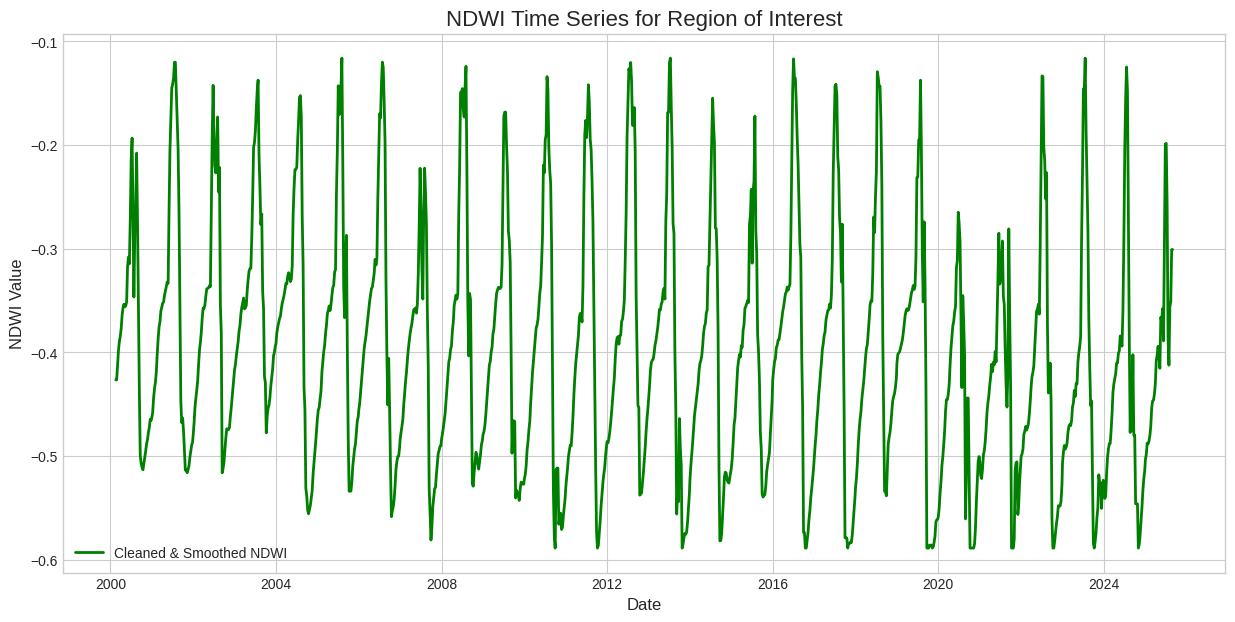

In [ ]:
import matplotlib.pyplot as plt

# Set up the plot
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(15, 7))

# Plot the cleaned and smoothed data
ax.plot(df.index, df['ndwi_smoothed'],
        label='Cleaned & Smoothed NDWI', color='green', linewidth=2)

# Add titles and labels
ax.set_title('NDWI Time Series for Region of Interest', fontsize=16)
ax.set_ylabel('NDWI Value', fontsize=12)
ax.set_xlabel('Date', fontsize=12)
ax.legend()
ax.grid(True)

# Display the plot
plt.show()

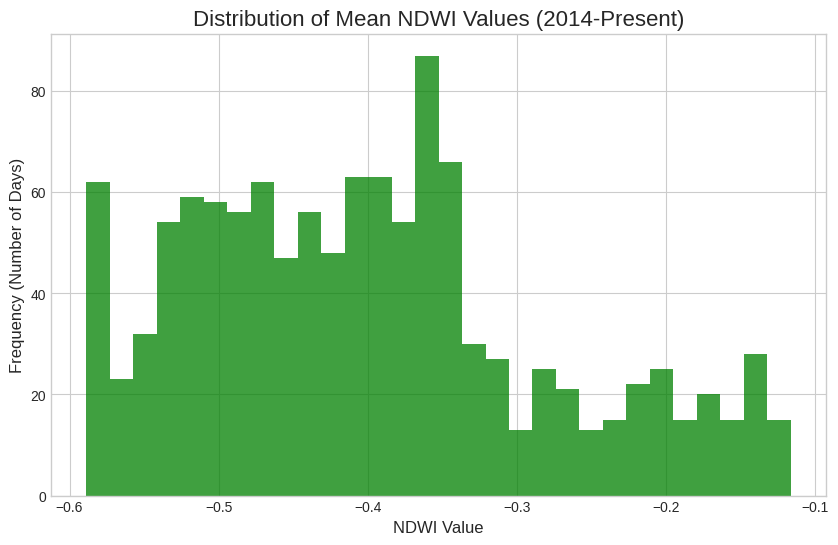

In [ ]:
# Set up the plot
plt.figure(figsize=(10, 6))

# Create a histogram of the cleaned NDVI values
plt.hist(df['ndwi_smoothed'], bins=30, color='green', alpha=0.75)

# Add titles and labels
plt.title('Distribution of Mean NDWI Values (2014-Present)', fontsize=16)
plt.xlabel('NDWI Value', fontsize=12)
plt.ylabel('Frequency (Number of Days)', fontsize=12)
plt.grid(True)

# Display the plot
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Load the CSV data
df = pd.read_csv(
    '/content/gangapur_ndwi_time_series_2000_2025.csv',
    parse_dates=['date'],
    index_col='date'
)

# Use the smoothed NDVI data we prepared before
# (For simplicity, we'll re-do the cleaning steps here)
df['ndwi'].interpolate(method='linear', inplace=True)
lower_bound = df['ndwi'].quantile(0.05)
upper_bound = df['ndwi'].quantile(0.95)
df['ndwi'] = df['ndwi'].clip(lower=lower_bound, upper=upper_bound)
df['ndwi_smoothed'] = df['ndwi'].rolling(window=3, center=True).mean()
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)

# --- Prepare data for LSTM ---
# 1. Get the time series data as a NumPy array
time_series = df['ndwi_smoothed'].values.reshape(-1, 1)

# 2. Scale the data to be between 0 and 1
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_series = scaler.fit_transform(time_series)

Training data shape: (923, 20, 1) (923,)
Test data shape: (231, 20, 1) (231,)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100)            │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,901 (159.77 KB)

 Trainable params: 40,901 (159.77 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.1247 - val_loss: 0.0326 - learning_rate: 0.0010
Epoch 2/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0328 - val_loss: 0.0219 - learning_rate: 0.0010
Epoch 3/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0203 - val_loss: 0.0206 - learning_rate: 0.0010
Epoch 4/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0169 - val_loss: 0.0183 - learning_rate: 0.0010
Epoch 5/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0125 - val_loss: 0.0181 - learning_rate: 0.0010
Epoch 6/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0109 - val_loss: 0.0179 - learning_rate: 0.0010
Epoch 7/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0102 - val_loss: 0.0159 - learning_rate: 0.0010
Epoch 8/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0091 - val_loss: 0.0173 - learning_rate: 0.0010
Epoch 9/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0090 - val_loss: 0.0154 - learning_rate: 0.0010
Epoch 10/1

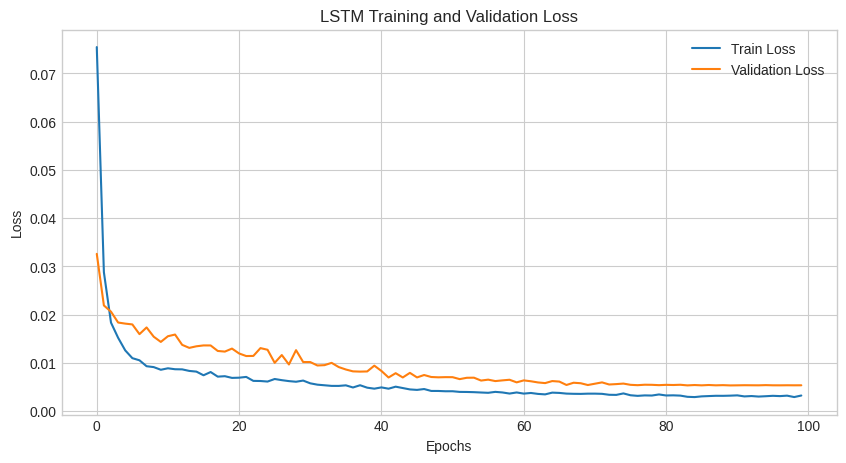

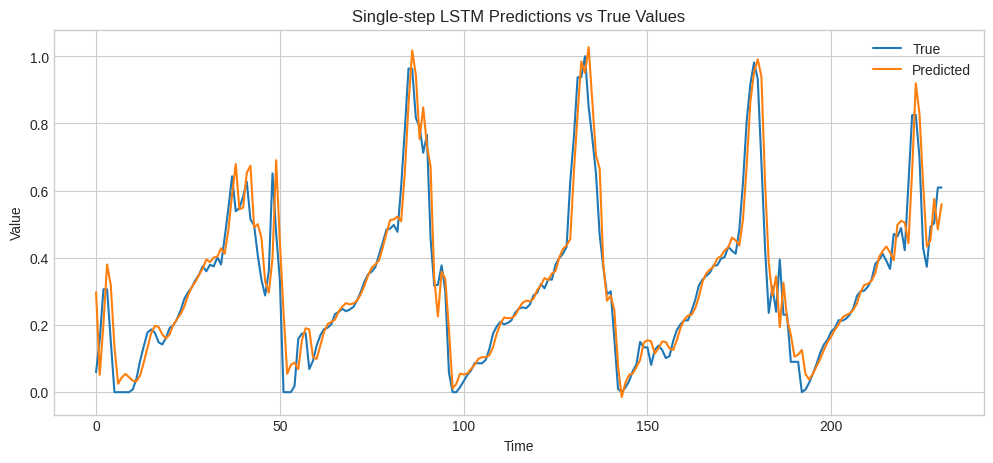

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# -------------------------------
# Assume scaled_series is your normalized 1D time series (shape: [samples,1])
# -------------------------------

# Function to create single-step sequences
def create_lstm_sequences(data, n_steps):
    X, y = [], []
    for i in range(len(data) - n_steps):
        X.append(data[i:(i + n_steps), 0])
        y.append(data[i + n_steps, 0])
    return np.array(X), np.array(y)

# Parameters
n_steps = 20  # number of past timesteps
batch_size = 32

# Create sequences
X, y = create_lstm_sequences(scaled_series, n_steps)

# Reshape X to [samples, timesteps, features]
X = X.reshape((X.shape[0], X.shape[1], 1))

# Train-test split
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("Training data shape:", X_train.shape, y_train.shape)
print("Test data shape:", X_test.shape, y_test.shape)

# -------------------------------
# Build LSTM model
# -------------------------------
model = Sequential([
    LSTM(100, activation='tanh', input_shape=(n_steps,1)),
    Dropout(0.2),
    Dense(1)  # single-step output
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

# Learning rate scheduler
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)

# -------------------------------
# Train the model
# -------------------------------
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=batch_size,
    validation_data=(X_test, y_test),
    callbacks=[reduce_lr],
    verbose=1
)

print("Training complete!")

# -------------------------------
# Evaluate performance
# -------------------------------
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Test Performance:")
print({'MSE': mse, 'MAE': mae, 'R² Score': r2})

# -------------------------------
# Plot training vs validation loss
# -------------------------------
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# -------------------------------
# Plot predictions vs true values
# -------------------------------
plt.figure(figsize=(12,5))
plt.plot(y_test, label='True')
plt.plot(y_pred, label='Predicted')
plt.title('Single-step LSTM Predictions vs True Values')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.show()


In [ ]:
# If you used MinMaxScaler to scale your series
future_predictions_original = scaler.inverse_transform(future_predictions.reshape(-1,1))
print("Next 10 predicted values (original scale):")
print(future_predictions_original.flatten())


Next 10 predicted values (original scale):
[-0.30742714 -0.32006466 -0.32955012 -0.33291072 -0.33471417 -0.33753544
 -0.3414652  -0.34558368 -0.34936327 -0.35261744]


Test Performance:
{'MSE': 0.005905302507077458, 'MAE': 0.0471147047637157, 'R2': 0.8882119151727191}


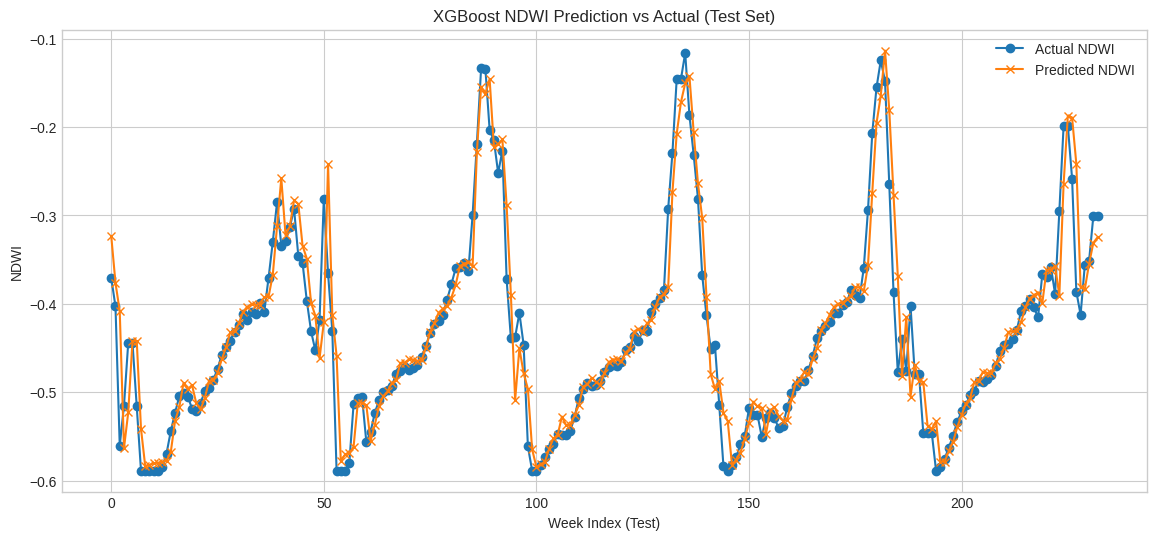

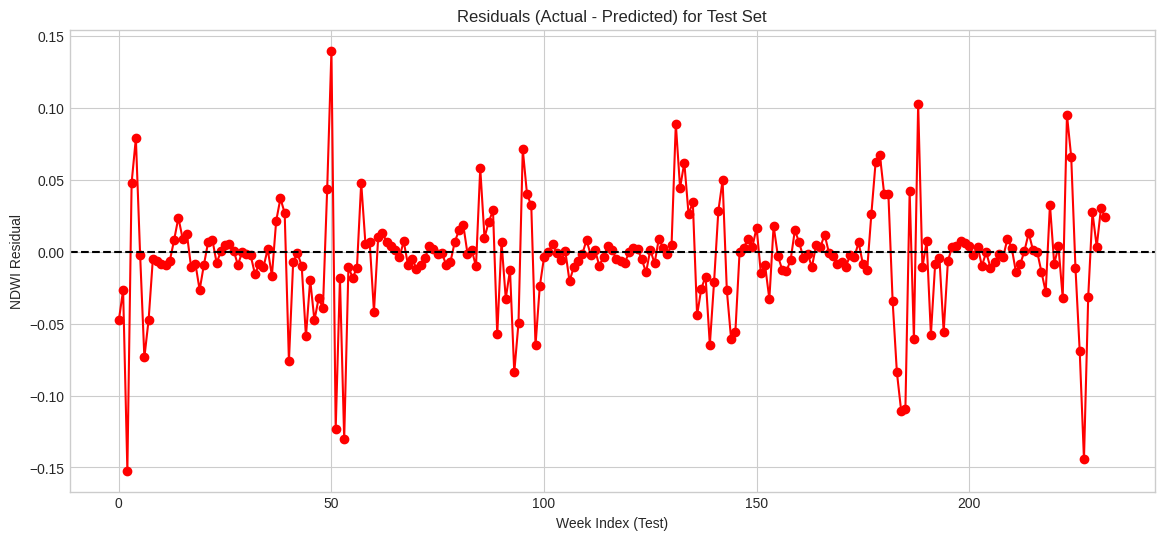

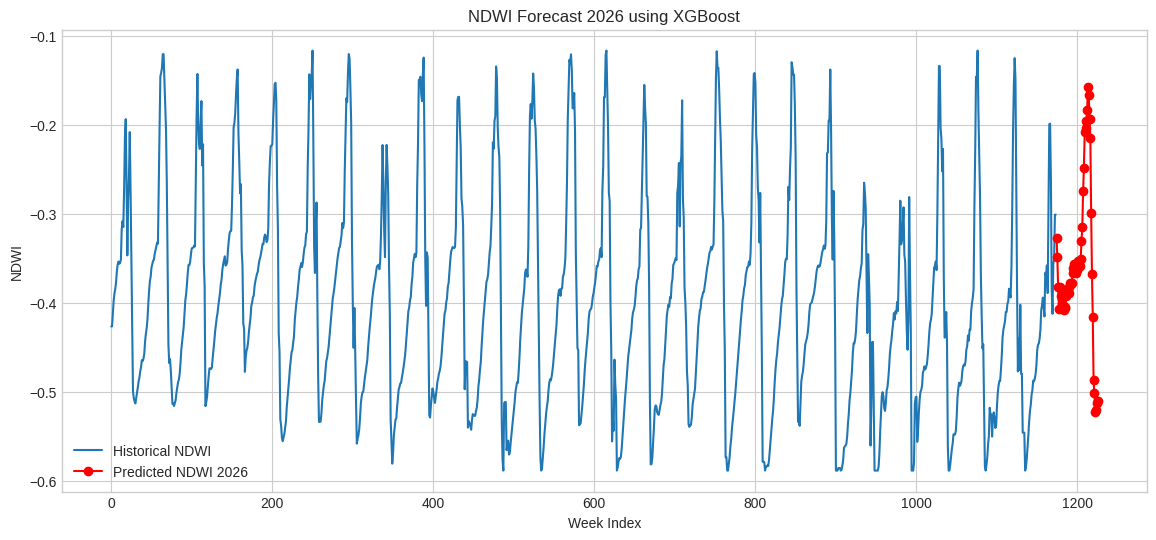

First 10 predicted NDWI values for 2026:
[-0.32703352 -0.34880418 -0.38235158 -0.40678334 -0.3824224  -0.383958
 -0.3919515  -0.401543   -0.40288818 -0.4080942 ]


In [ ]:
# 1️⃣ Install
!pip install xgboost --quiet

# 2️⃣ Imports
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# 3️⃣ Load dataset
df = pd.read_csv("/content/gangapur_ndwi_time_series_2000_2025.csv")  # Replace with your NDWI CSV
df.columns = df.columns.str.strip()

# 4️⃣ Keep original NDWI for plotting
df['original_ndwi'] = df['ndwi']

# 5️⃣ Handle missing values by linear interpolation
df['ndwi'].interpolate(method='linear', inplace=True)
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)

# 6️⃣ Handle outliers (clip to 5th-95th percentile)
lower_bound = df['ndwi'].quantile(0.05)
upper_bound = df['ndwi'].quantile(0.95)
df['ndwi'] = df['ndwi'].clip(lower=lower_bound, upper=upper_bound)

# 7️⃣ Smooth using rolling mean
df['ndwi_smoothed'] = df['ndwi'].rolling(window=3, center=True).mean()
df['ndwi_smoothed'].fillna(method='bfill', inplace=True)
df['ndwi_smoothed'].fillna(method='ffill', inplace=True)

# 8️⃣ Scale NDWI
scaler = MinMaxScaler()
df['scaled'] = scaler.fit_transform(df[['ndwi_smoothed']])

# 9️⃣ Create lag features
def create_lag_features(series, lags=10):
    X, y = [], []
    for i in range(lags, len(series)):
        X.append(series[i-lags:i])
        y.append(series[i])
    X, y = np.array(X), np.array(y)

    # Remove any NaNs
    valid_idx = ~np.isnan(y)
    return X[valid_idx], y[valid_idx]

n_lags = 10
X, y = create_lag_features(df['scaled'].values, n_lags)

# 10️⃣ Train-test split
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# 11️⃣ Train XGBoost
model = XGBRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    objective='reg:squarederror'
)
model.fit(X_train, y_train)

# 12️⃣ Predictions on test
y_pred = model.predict(X_test)
print("Test Performance:")
print({
    'MSE': mean_squared_error(y_test, y_pred),
    'MAE': mean_absolute_error(y_test, y_pred),
    'R2': r2_score(y_test, y_pred)
})

# 13️⃣ Inverse scale predictions
y_test_original = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()
y_pred_original = scaler.inverse_transform(y_pred.reshape(-1,1)).flatten()

# 14️⃣ Plot Predicted vs Actual
plt.figure(figsize=(14,6))
plt.plot(y_test_original, label='Actual NDWI', marker='o')
plt.plot(y_pred_original, label='Predicted NDWI', marker='x')
plt.title('XGBoost NDWI Prediction vs Actual (Test Set)')
plt.xlabel('Week Index (Test)')
plt.ylabel('NDWI')
plt.legend()
plt.show()

# 15️⃣ Plot Residuals
residuals = y_test_original - y_pred_original
plt.figure(figsize=(14,6))
plt.plot(residuals, color='red', marker='o')
plt.axhline(0, linestyle='--', color='black')
plt.title('Residuals (Actual - Predicted) for Test Set')
plt.xlabel('Week Index (Test)')
plt.ylabel('NDWI Residual')
plt.show()

# 16️⃣ Forecast next year (52 weeks)
last_values = df['scaled'].values[-n_lags:].tolist()
future_pred_scaled = []
for _ in range(52):
    x_input = np.array(last_values[-n_lags:]).reshape(1, -1)
    next_pred = model.predict(x_input)[0]
    future_pred_scaled.append(next_pred)
    last_values.append(next_pred)

future_pred = scaler.inverse_transform(np.array(future_pred_scaled).reshape(-1,1)).flatten()

# 17️⃣ Plot forecast
plt.figure(figsize=(14,6))
plt.plot(df['ndwi_smoothed'], label='Historical NDWI')
plt.plot(range(len(df), len(df)+52), future_pred, 'r-o', label='Predicted NDWI 2026')
plt.xlabel('Week Index')
plt.ylabel('NDWI')
plt.title('NDWI Forecast 2026 using XGBoost')
plt.legend()
plt.show()

print("First 10 predicted NDWI values for 2026:")
print(future_pred[:10])


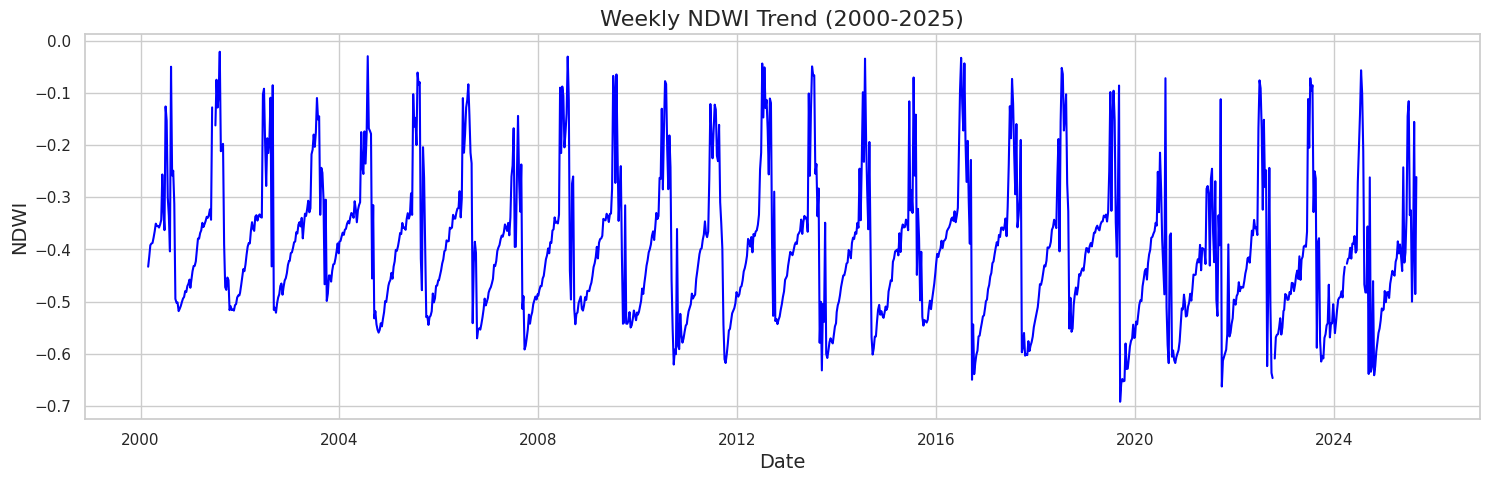

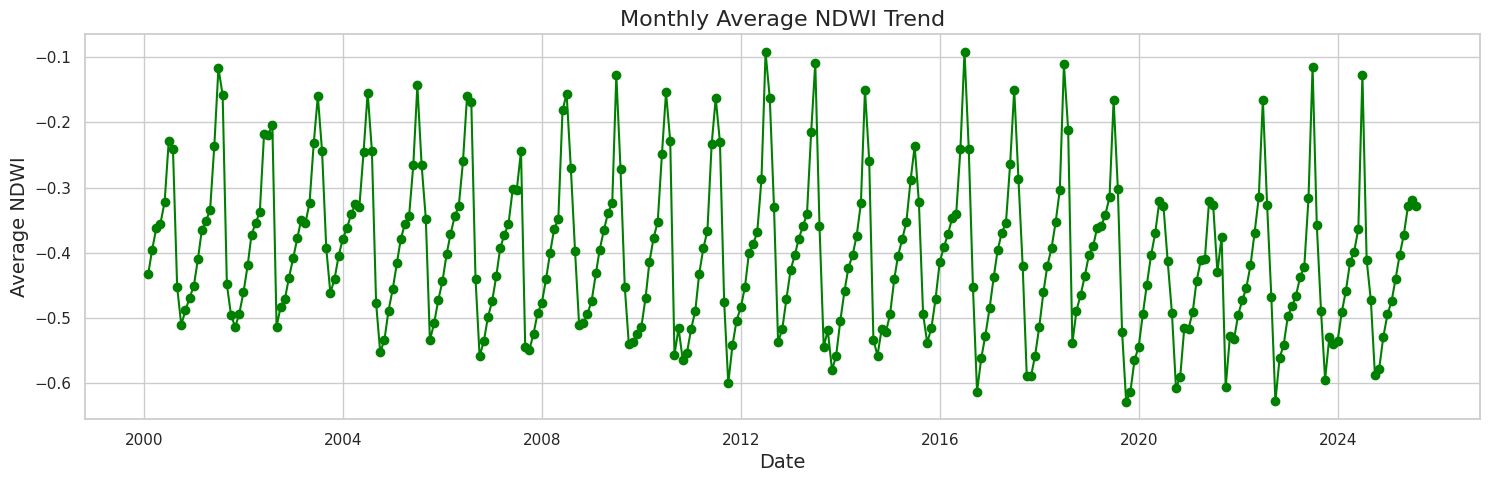

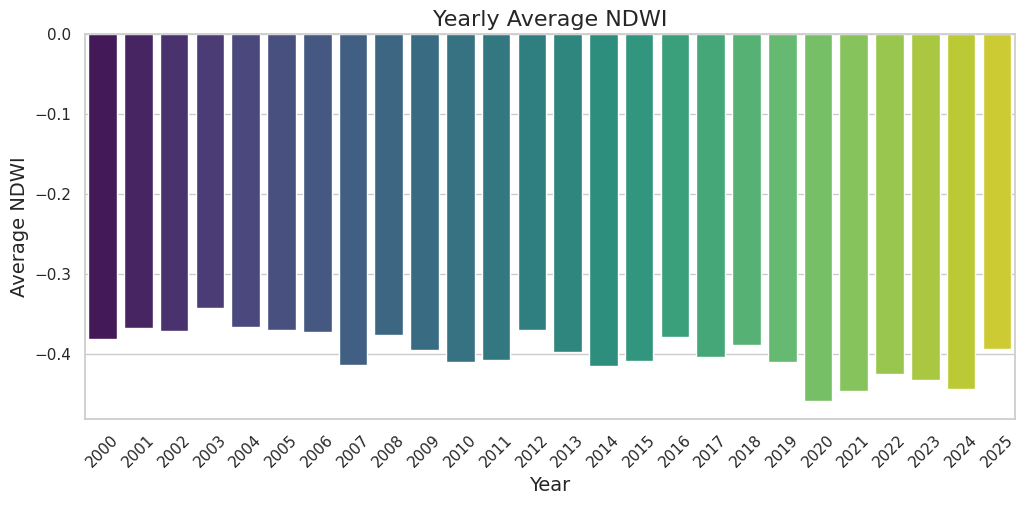

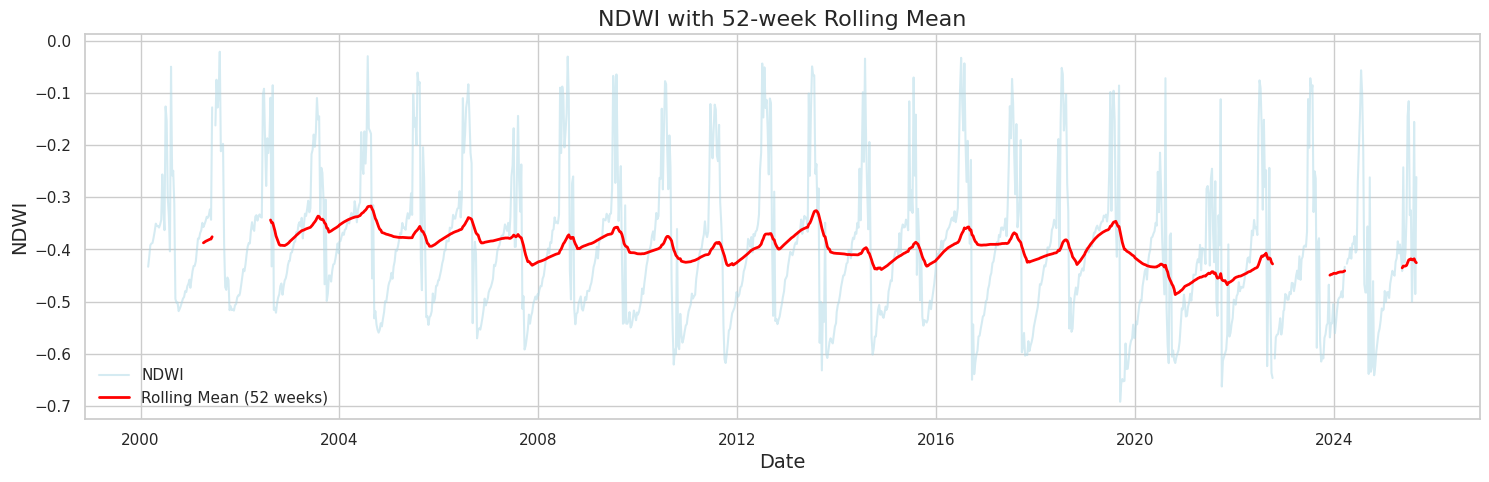

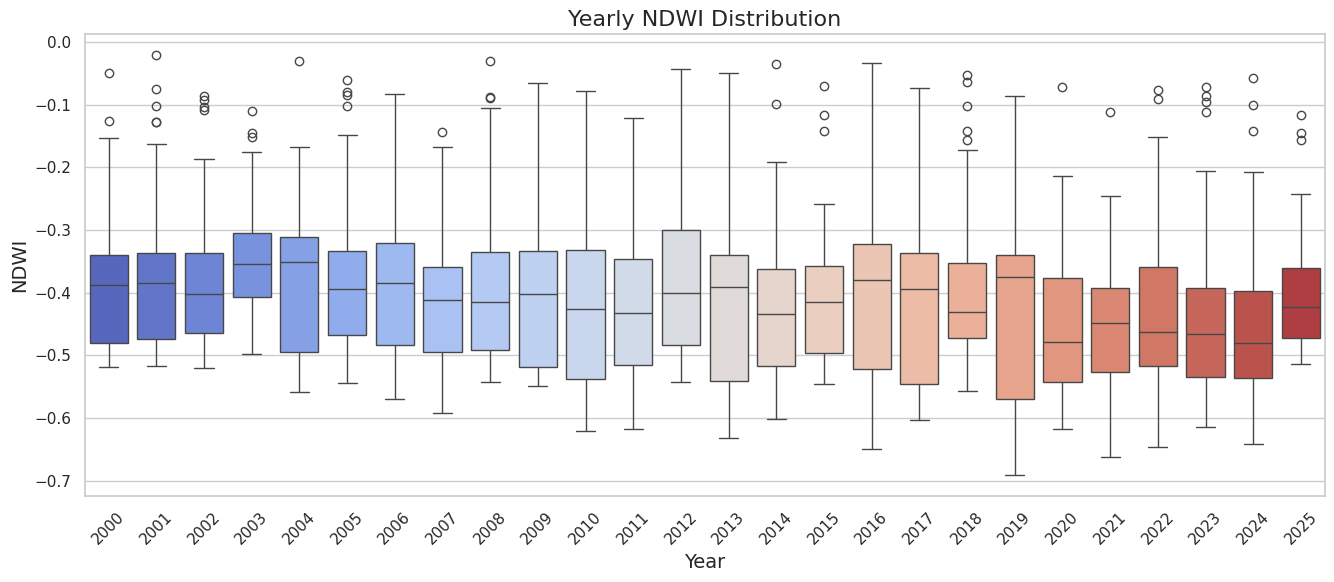

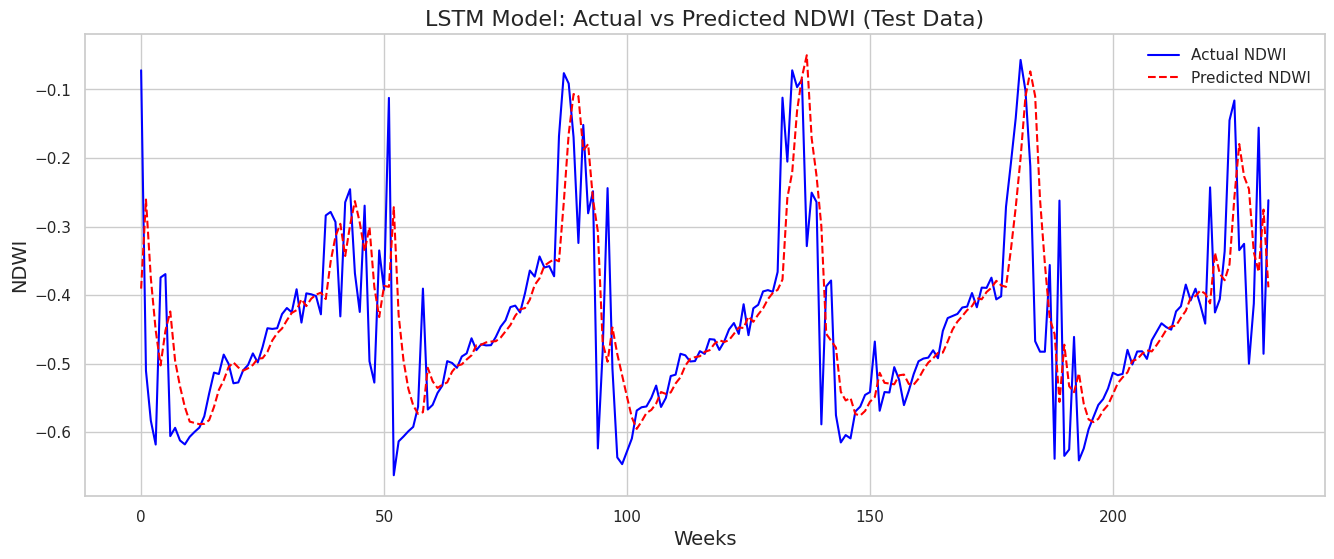

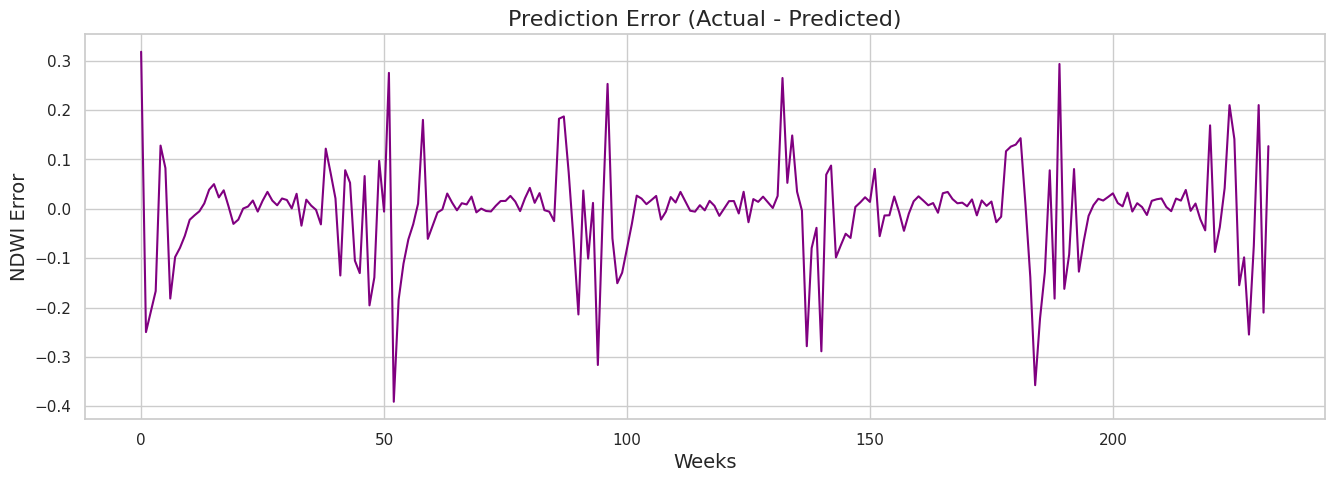

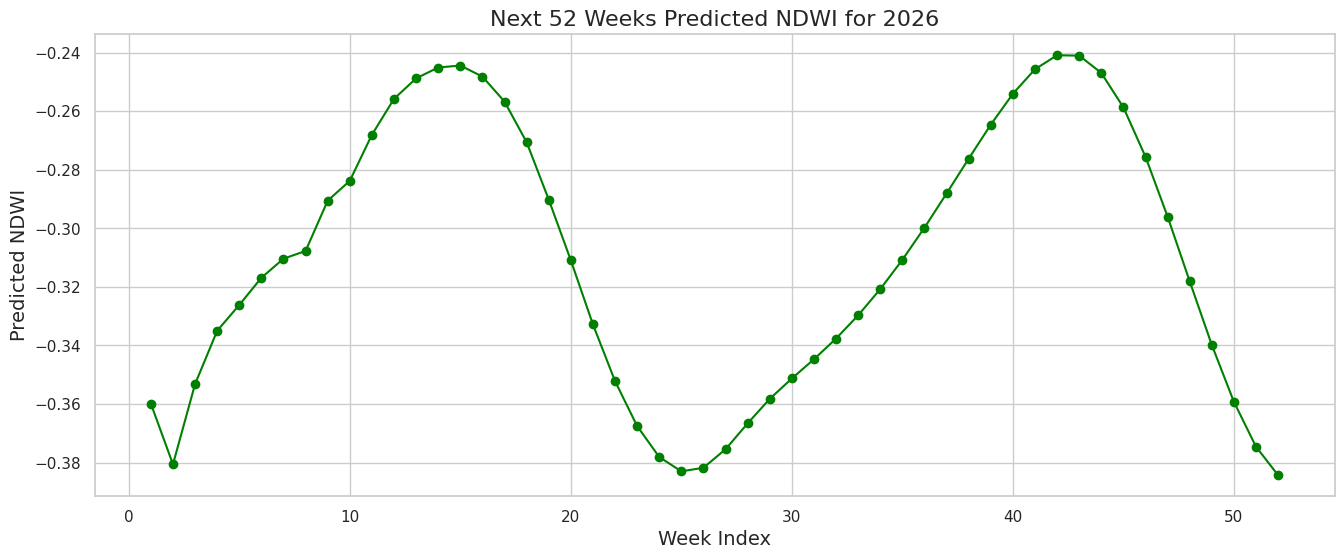

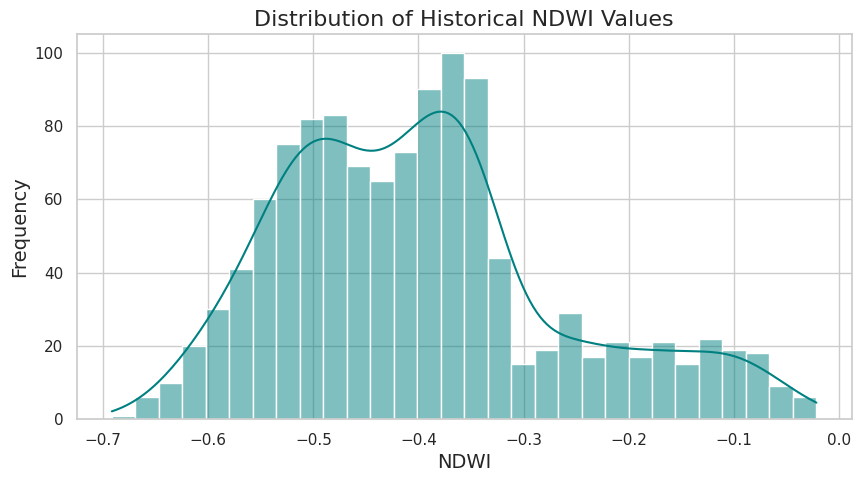

In [ ]:
# -------------------------------
# 0️⃣ Required Libraries
# -------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# -------------------------------
# 1️⃣ Load NDWI dataset
# -------------------------------
df = pd.read_csv('/content/gangapur_ndwi_time_series_2000_2025.csv')
df.columns = df.columns.str.strip()  # remove extra spaces

# Convert 'date' column to datetime
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['week'] = df['date'].dt.isocalendar().week

sns.set(style="whitegrid")

# -------------------------------
# 2️⃣ Weekly NDWI Trend (original data)
# -------------------------------
plt.figure(figsize=(18,5))
plt.plot(df['date'], df['ndwi'], color='blue')
plt.title('Weekly NDWI Trend (2000-2025)', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('NDWI', fontsize=14)
plt.show()

# -------------------------------
# 3️⃣ Monthly Average NDWI
# -------------------------------
monthly_avg = df.groupby(['year','month'])['ndwi'].mean().reset_index()
monthly_avg['date'] = pd.to_datetime(monthly_avg[['year','month']].assign(DAY=1))

plt.figure(figsize=(18,5))
plt.plot(monthly_avg['date'], monthly_avg['ndwi'], color='green', marker='o')
plt.title('Monthly Average NDWI Trend', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Average NDWI', fontsize=14)
plt.show()

# -------------------------------
# 4️⃣ Yearly Average NDWI
# -------------------------------
yearly_avg = df.groupby('year')['ndwi'].mean()

plt.figure(figsize=(12,5))
sns.barplot(x=yearly_avg.index, y=yearly_avg.values, palette='viridis')
plt.title('Yearly Average NDWI', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Average NDWI', fontsize=14)
plt.xticks(rotation=45)
plt.show()

# -------------------------------
# 5️⃣ Rolling Mean (Seasonal Smoothing)
# -------------------------------
rolling = df['ndwi'].rolling(window=52).mean()  # yearly window

plt.figure(figsize=(18,5))
plt.plot(df['date'], df['ndwi'], color='lightblue', alpha=0.5, label='NDWI')
plt.plot(df['date'], rolling, color='red', linewidth=2, label='Rolling Mean (52 weeks)')
plt.title('NDWI with 52-week Rolling Mean', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('NDWI', fontsize=14)
plt.legend()
plt.show()

# -------------------------------
# 6️⃣ Boxplot per Year
# -------------------------------
plt.figure(figsize=(16,6))
sns.boxplot(x='year', y='ndwi', data=df, palette='coolwarm')
plt.title('Yearly NDWI Distribution', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('NDWI', fontsize=14)
plt.xticks(rotation=45)
plt.show()

# -------------------------------
# 7️⃣ Test vs Predicted NDWI (from previous LSTM)
# -------------------------------
plt.figure(figsize=(16,6))
plt.plot(range(len(y_test_original)), y_test_original, color='blue', label='Actual NDWI')
plt.plot(range(len(y_pred_original)), y_pred_original, color='red', linestyle='--', label='Predicted NDWI')
plt.title('LSTM Model: Actual vs Predicted NDWI (Test Data)', fontsize=16)
plt.xlabel('Weeks', fontsize=14)
plt.ylabel('NDWI', fontsize=14)
plt.legend()
plt.show()

# -------------------------------
# 8️⃣ Prediction Error
# -------------------------------
plt.figure(figsize=(16,5))
error = y_test_original - y_pred_original
plt.plot(range(len(error)), error, color='purple')
plt.title('Prediction Error (Actual - Predicted)', fontsize=16)
plt.xlabel('Weeks', fontsize=14)
plt.ylabel('NDWI Error', fontsize=14)
plt.show()

# -------------------------------
# 9️⃣ Future NDWI Predictions (Next 52 Weeks)
# -------------------------------
plt.figure(figsize=(16,6))
plt.plot(range(1,53), future_pred_original, marker='o', color='green')
plt.title('Next 52 Weeks Predicted NDWI for 2026', fontsize=16)
plt.xlabel('Week Index', fontsize=14)
plt.ylabel('Predicted NDWI', fontsize=14)
plt.grid(True)
plt.show()

# -------------------------------
# 🔟 NDWI Distribution + KDE
# -------------------------------
plt.figure(figsize=(10,5))
sns.histplot(df['ndwi'], bins=30, kde=True, color='teal')
plt.title('Distribution of Historical NDWI Values', fontsize=16)
plt.xlabel('NDWI', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.show()


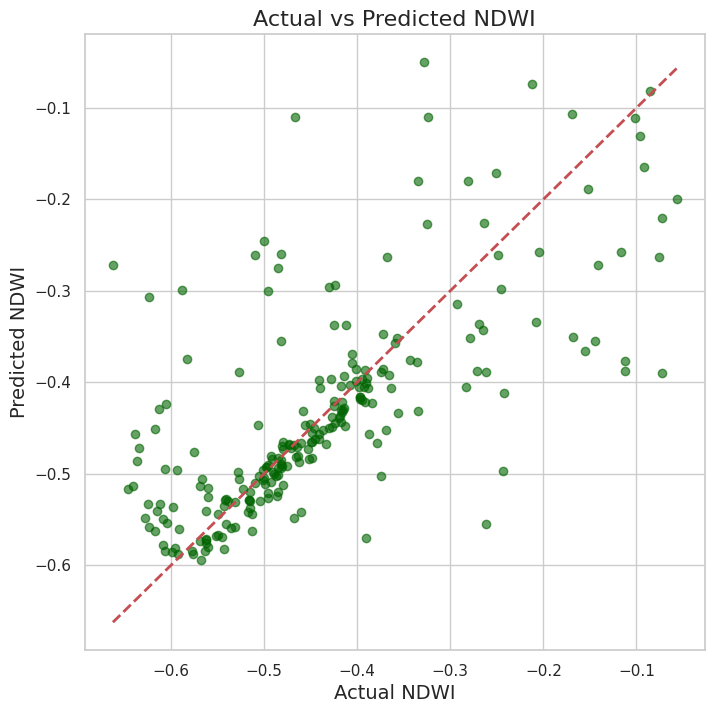

In [ ]:
plt.figure(figsize=(8,8))
plt.scatter(y_test_original, y_pred_original, color='darkgreen', alpha=0.6)
plt.plot([min(y_test_original), max(y_test_original)],
         [min(y_test_original), max(y_test_original)], 'r--', lw=2)
plt.title('Actual vs Predicted NDWI', fontsize=16)
plt.xlabel('Actual NDWI', fontsize=14)
plt.ylabel('Predicted NDWI', fontsize=14)
plt.grid(True)
plt.show()


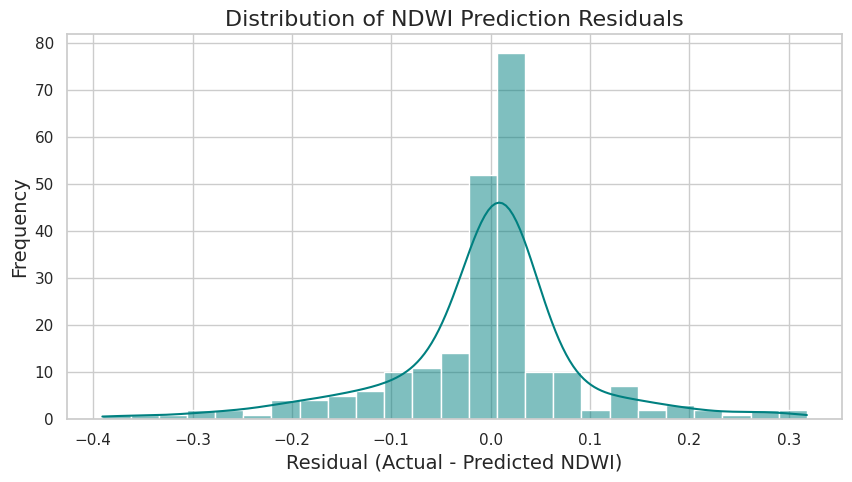

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute residuals for NDWI
residuals_ndwi = y_test_original - y_pred_original

# Plot histogram + KDE
plt.figure(figsize=(10,5))
sns.histplot(residuals_ndwi, bins=25, kde=True, color='teal')
plt.title('Distribution of NDWI Prediction Residuals', fontsize=16)
plt.xlabel('Residual (Actual - Predicted NDWI)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(True)
plt.show()


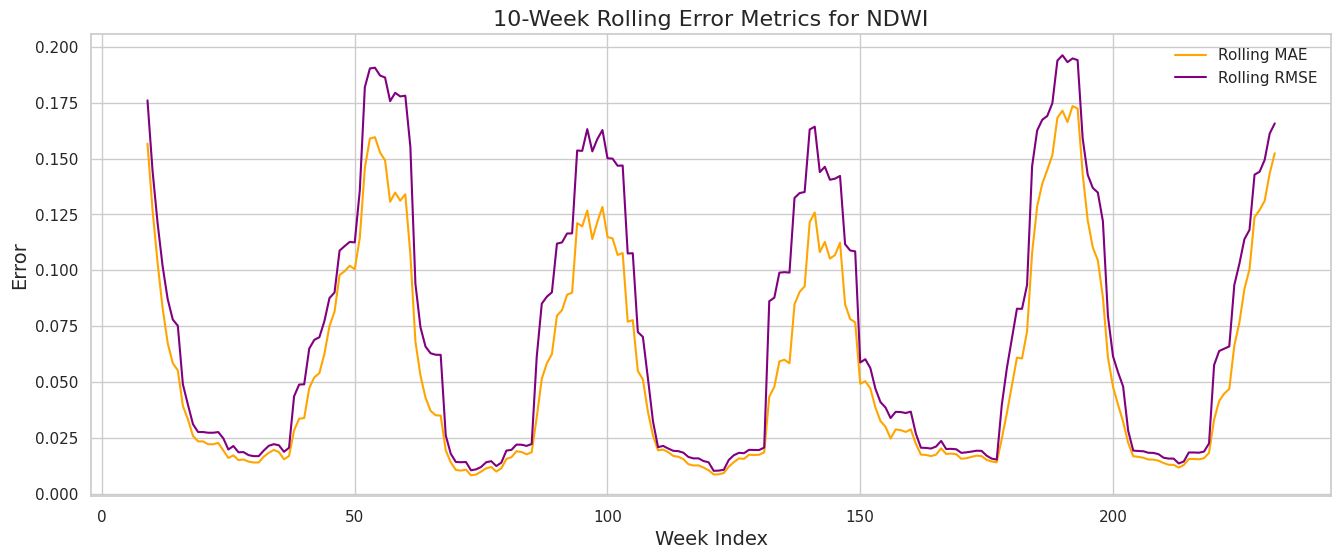

In [ ]:

window = 10  # 10-week rolling window

# Compute rolling MAE and RMSE
rolling_mae_ndwi = pd.Series(np.abs(residuals_ndwi)).rolling(window=window).mean()
rolling_rmse_ndwi = pd.Series(residuals_ndwi**2).rolling(window=window).mean().apply(np.sqrt)

# Plot rolling errors
plt.figure(figsize=(16,6))
plt.plot(rolling_mae_ndwi, label='Rolling MAE', color='orange')
plt.plot(rolling_rmse_ndwi, label='Rolling RMSE', color='purple')
plt.title(f'{window}-Week Rolling Error Metrics for NDWI', fontsize=16)
plt.xlabel('Week Index', fontsize=14)
plt.ylabel('Error', fontsize=14)
plt.legend()
plt.grid(True)
plt.show()


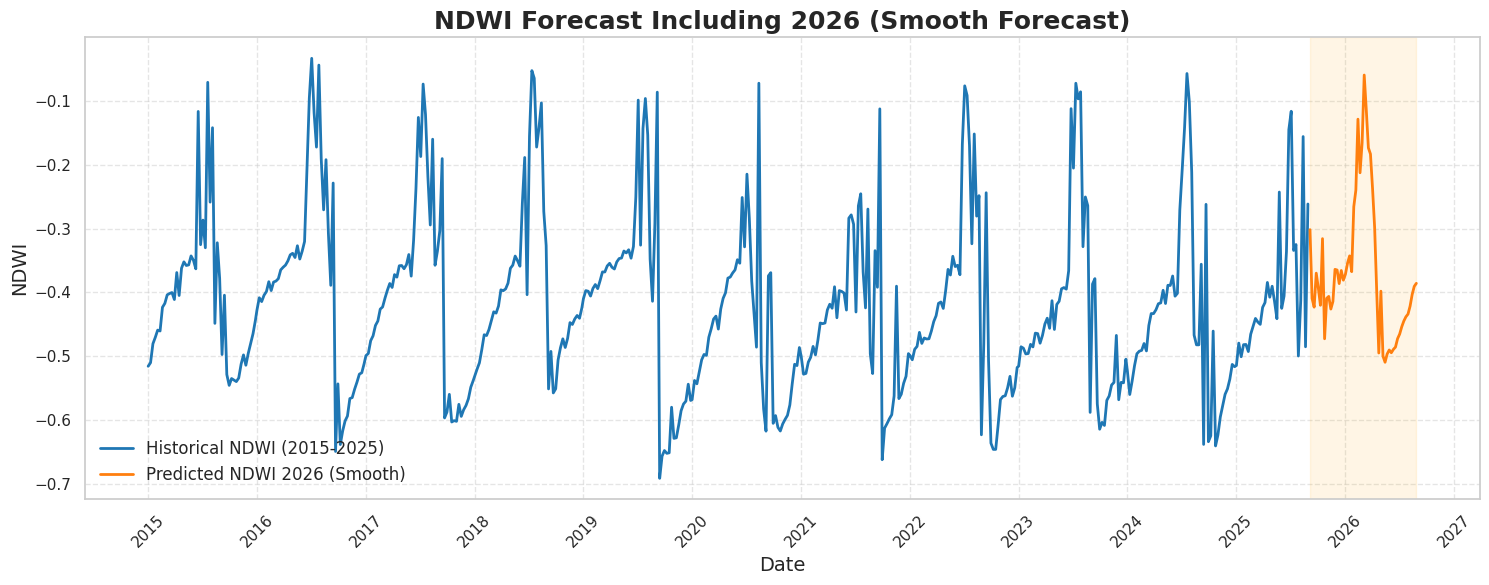

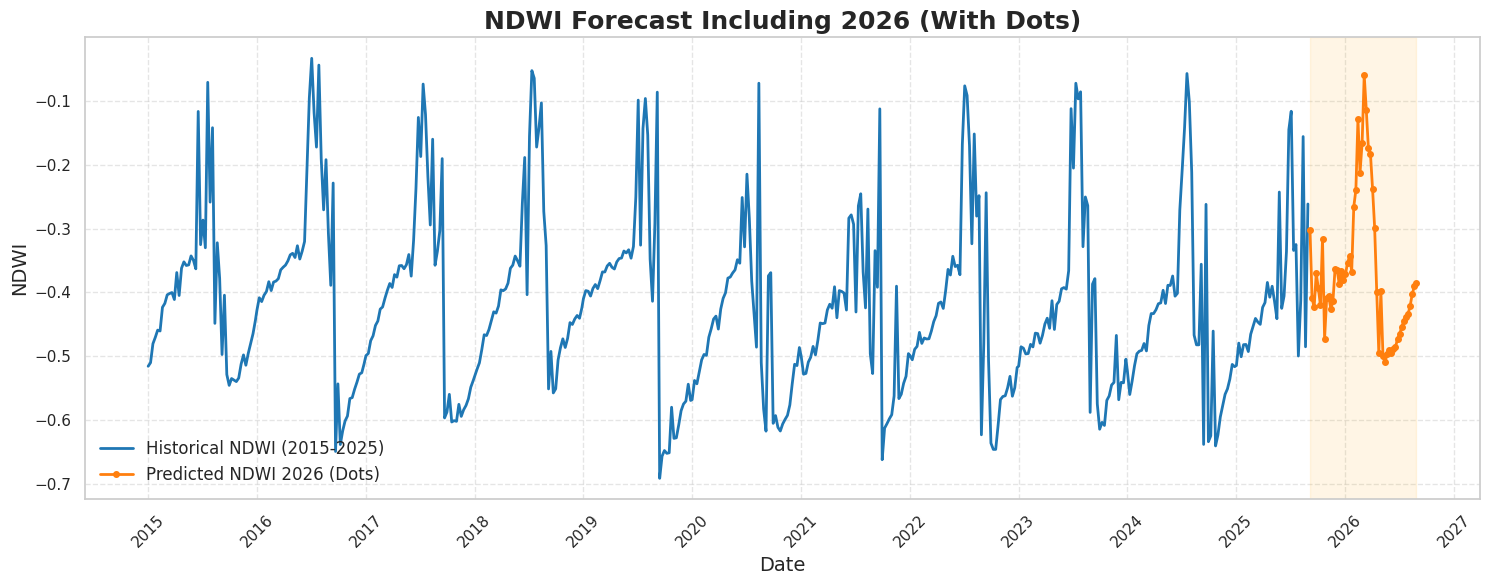

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Filter historical data from 2015 onwards
df_recent = df[df['date'] >= '2015-01-01']

# -------------------------------
# 1️⃣ Smooth Forecast Line
# -------------------------------
plt.figure(figsize=(18,6))

# Historical NDWI
plt.plot(df_recent['date'], df_recent['ndwi'], label='Historical NDWI (2015-2025)',
         color='#1f77b4', linewidth=2)

# Smooth forecast line (no markers)
plt.plot(weekly_dates_2026, future_pred, label='Predicted NDWI 2026 (Smooth)',
         color='#ff7f0e', linewidth=2)

# Highlight forecast area
plt.axvspan(weekly_dates_2026[0], weekly_dates_2026[-1], color='orange', alpha=0.1)

# Formatting
plt.title('NDWI Forecast Including 2026 (Smooth Forecast)', fontsize=18, weight='bold')
plt.xlabel('Date', fontsize=14)
plt.ylabel('NDWI', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Date formatting
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

plt.show()

# -------------------------------
# 2️⃣ Forecast with Dots
# -------------------------------
plt.figure(figsize=(18,6))

# Historical NDWI
plt.plot(df_recent['date'], df_recent['ndwi'], label='Historical NDWI (2015-2025)',
         color='#1f77b4', linewidth=2)

# Forecast with dots
plt.plot(weekly_dates_2026, future_pred, label='Predicted NDWI 2026 (Dots)',
         color='#ff7f0e', linewidth=2, marker='o', markersize=4)

# Highlight forecast area
plt.axvspan(weekly_dates_2026[0], weekly_dates_2026[-1], color='orange', alpha=0.1)

# Formatting
plt.title('NDWI Forecast Including 2026 (With Dots)', fontsize=18, weight='bold')
plt.xlabel('Date', fontsize=14)
plt.ylabel('NDWI', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Date formatting
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

plt.show()
